In [1]:
import joblib as jb
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import RFECV
import matplotlib.pyplot as plt


In [2]:
import sys
import os

In [4]:
sys.path.append(os.path.abspath(".."))

In [5]:
from src.data_utils import (load_data)


In [6]:
estimator = LogisticRegression(
    max_iter=1000,
    solver="lbfgs",
)

In [7]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [8]:
rfecv = RFECV(
    estimator=estimator,
    step=1,                # removes 1 feature per iteration
    cv=cv,
    scoring="f1_macro",    # IMPORTANT for imbalance
    n_jobs=-1              # speeds it up
)

In [9]:
X_train= load_data("../data/X_train_with_new_features.csv")
y_train= load_data("../data/y_train_new.csv")

DataFrame successfully loaded.
Shape: (47046, 76)
DataFrame successfully loaded.
Shape: (47046, 1)


In [10]:
rfecv.fit(X_train, y_train)

/Users/emerie/Desktop/RediStuffs/DataC/PumpHealth/venv/Pumphealth_venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/emerie/Desktop/RediStuffs/DataC/PumpHealth/venv/Pumphealth_venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/emerie/Desktop/RediStuffs/DataC/PumpHealth/venv/Pumphealth_venv/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/Users/emerie/Desktop/RediStuff

,estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance either through a ``coef_``attribute or through a ``feature_importances_`` attribute.,LogisticRegre...max_iter=1000)
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.Note that the last iteration may remove fewer than ``step`` features inorder to reach ``min_features_to_select``.",1
,"min_features_to_select min_features_to_select: int, default=1The minimum number of features to be selected. This number of featureswill always be scored, even if the difference between the originalfeature count and ``min_features_to_select`` isn't divisible by``step``... versionadded:: 0.20",1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If theestimator is not a classifier or if ``y`` is neither binary nor multiclass,:class:`~sklearn.model_selection.KFold` is used.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value of None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"scoring scoring: str or callable, default=NoneScoring method to evaluate the :class:`RFE` selectors' performance. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: the `estimator`'s :ref:`default evaluation criterion ` is used.",'f1_macro'
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"n_jobs n_jobs: int or None, default=NoneNumber of cores to run in parallel while fitting across folds.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",-1
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance.For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case of:class:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must b

In [11]:
selected_features = X_train.columns[rfecv.support_]
print("Number of selected features:", len(selected_features))
print(selected_features)

Number of selected features: 75
Index(['longitude', 'latitude', 'amount_tsh_log', 'population_log', 'pump_age',
       'pump_is_new', 'pump_age_band', 'height_band', 'quantity_score',
       'is_paid_water', 'is_water_safe', 'lga_te', 'basin_Internal',
       'basin_Lake Nyasa', 'basin_Lake Rukwa', 'basin_Lake Tanganyika',
       'basin_Lake Victoria', 'basin_Pangani', 'basin_Rufiji',
       'basin_Ruvuma / Southern Coast', 'basin_Wami / Ruvu',
       'public_meeting_False', 'public_meeting_True', 'permit_False',
       'permit_True', 'quantity_dry', 'quantity_enough',
       'quantity_insufficient', 'quantity_seasonal', 'payment_never pay',
       'payment_other', 'payment_pay annually', 'payment_pay monthly',
       'payment_pay per bucket', 'payment_pay when scheme fails',
       'extraction_type_afridev', 'extraction_type_gravity',
       'extraction_type_india mark ii', 'extraction_type_ksb',
       'extraction_type_mono', 'extraction_type_nira/tanira',
       'extraction_type_oth

In [12]:
jb.dump(
    selected_features,
    "../models/selected_features.pkl"
)

['../models/selected_features.pkl']

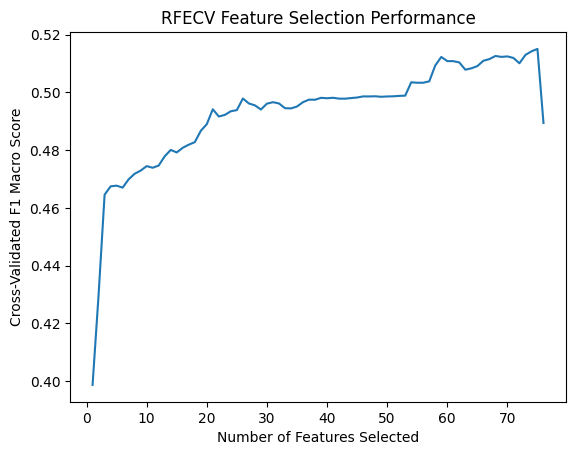

In [13]:

plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"]) + 1),
         rfecv.cv_results_["mean_test_score"])

plt.xlabel("Number of Features Selected")
plt.ylabel("Cross-Validated F1 Macro Score")
plt.title("RFECV Feature Selection Performance")
plt.show()